In [5]:
import kagglehub
import shutil
import os

downloaded_path = kagglehub.dataset_download("stkbailey/nashville-meetup")
dest_path = "data/raw/"
os.makedirs(os.path.dirname(dest_path), exist_ok=True)

shutil.copytree(downloaded_path, dest_path, dirs_exist_ok=True)
print(f"Dataset moved to: {dest_path}")

100%|██████████| 10.8M/10.8M [00:00<00:00, 27.5MB/s]

Extracting files...


Dataset moved to: data/raw/


In [8]:
import pandas as pd
import os

data_dir = 'data/raw/'

# The files visible in your previous screenshot
files_to_check = [
    'meta-events.csv',
    'meta-groups.csv',
    'meta-members.csv',
    'rsvps.csv',
    'member-to-group-edges.csv',
    'member-edges.csv',
    'group-edges.csv'
]

for file in files_to_check:
    file_path = os.path.join(data_dir, file)
    if os.path.exists(file_path):
        print(f"========== {file} ==========")
        # Read only the first 3 rows to keep your terminal output clean
        df = pd.read_csv(file_path, nrows=3)
        print(f"COLUMNS: {df.columns.tolist()}\n")
        print(df)
        print("\n")
    else:
        print(f"========== {file} NOT FOUND ==========\n")

========== meta-events.csv ==========
COLUMNS: ['event_id', 'group_id', 'name', 'time']

       event_id  group_id                                               name  \
0     243930425  26140018  2017 Nashville Walk to End Alzheimers - Octob...   
1     244208851  25604533                          Steak Dinner on the Patio   
2  pxlktnywnbfb  25973656                                    Schedule Meetup   

                  time  
0  2017-10-14 12:00:00  
1  2017-10-15 00:15:00  
2  2017-10-03 23:30:00  


========== meta-groups.csv ==========
COLUMNS: ['group_id', 'group_name', 'num_members', 'category_id', 'category_name', 'organizer_id', 'group_urlname']

   group_id                        group_name  num_members  category_id  \
0    339011           Nashville Hiking Meetup        15838           23   
1  19728145  Stepping Out Social Dance Meetup         1778            5   
2   6335372                  Nashville soccer         2869           32   

          category_name  organiz

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Setup
data_dir = 'data/raw/'
sns.set_theme(style="whitegrid")

# Load data (dropping the artifact 'Unnamed: 0' columns immediately)
events_df = pd.read_csv(os.path.join(data_dir, 'meta-events.csv'))
groups_df = pd.read_csv(os.path.join(data_dir, 'meta-groups.csv'))
members_df = pd.read_csv(os.path.join(data_dir, 'meta-members.csv'))
rsvps_df = pd.read_csv(os.path.join(data_dir, 'rsvps.csv')).drop(columns=['Unnamed: 0'], errors='ignore')
member_edges = pd.read_csv(os.path.join(data_dir, 'member-edges.csv')).drop(columns=['Unnamed: 0'], errors='ignore')

# 1. Temporal Alignment
# Convert event times to datetime objects
events_df['time'] = pd.to_datetime(events_df['time'], errors='coerce')

# Merge event timestamps and group IDs into the RSVP dataframe
rsvps_master = rsvps_df.merge(events_df[['event_id', 'time', 'name']], on='event_id', how='left')
rsvps_master = rsvps_master.merge(groups_df[['group_id', 'category_name', 'category_id']], on='group_id', how='left')

print("--- Master RSVP Table ---")
print(rsvps_master.info())
print(f"\nMissing Timestamps: {rsvps_master['time'].isna().sum()}")

--- Master RSVP Table ---
<class 'pandas.DataFrame'>
RangeIndex: 126813 entries, 0 to 126812
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   event_id       126813 non-null  str           
 1   member_id      126813 non-null  int64         
 2   group_id       126813 non-null  int64         
 3   time           126329 non-null  datetime64[us]
 4   name           126813 non-null  str           
 5   category_name  126813 non-null  str           
 6   category_id    126813 non-null  int64         
dtypes: datetime64[us](1), int64(3), str(3)
memory usage: 6.8 MB
None

Missing Timestamps: 484


/tmp/ipykernel_50465/1392973796.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=category_counts.index, x=category_counts.values, palette='viridis')


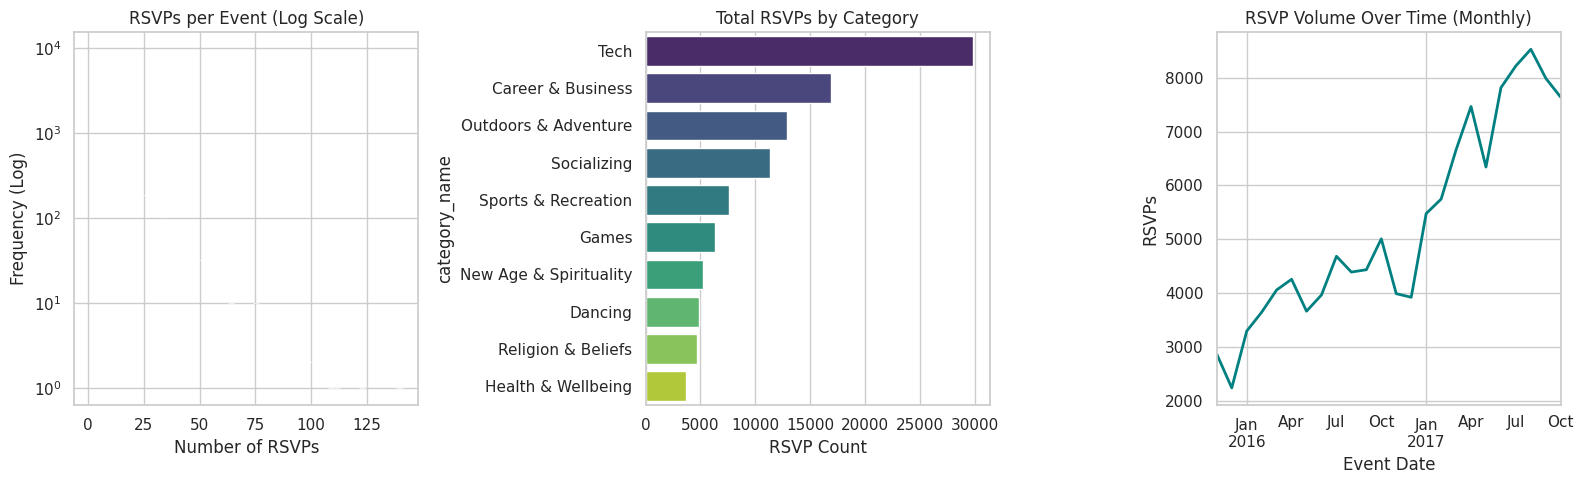


--- Event Size Statistics ---
count    19031.000000
mean         6.663496
std          9.347973
min          1.000000
50%          3.000000
75%          8.000000
90%         16.000000
95%         23.000000
99%         47.000000
max        141.000000
dtype: float64


In [12]:
plt.figure(figsize=(16, 5))

# --- Plot 1: Event Size Distribution ---
# How many RSVPs does a typical event get?
event_sizes = rsvps_master.groupby('event_id').size()

plt.subplot(1, 3, 1)
sns.histplot(event_sizes, bins=50, color='indigo', log_scale=(False, True))
plt.title('RSVPs per Event (Log Scale)')
plt.xlabel('Number of RSVPs')
plt.ylabel('Frequency (Log)')

# --- Plot 2: Category Popularity ---
# Which domains drive the most interaction? 
plt.subplot(1, 3, 2)
category_counts = rsvps_master['category_name'].value_counts().head(10)
sns.barplot(y=category_counts.index, x=category_counts.values, palette='viridis')
plt.title('Total RSVPs by Category')
plt.xlabel('RSVP Count')

# --- Plot 3: Temporal Event Frequency ---
# Identifying the timeline for your train/val/test split
plt.subplot(1, 3, 3)
rsvps_master.set_index('time').resample('ME').size().plot(color='teal', lw=2)
plt.title('RSVP Volume Over Time (Monthly)')
plt.xlabel('Event Date')
plt.ylabel('RSVPs')

plt.tight_layout()
plt.show()

print("\n--- Event Size Statistics ---")
print(event_sizes.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

In [ ]:
import networkx as nx

print("--- Analyzing Pre-computed Member Graph ---")
print(f"Total Edges Provided: {len(member_edges)}")

# Build a graph sample to calculate structural properties efficiently
# Using top 50,000 edges to avoid memory issues during EDA
G_sample = nx.from_pandas_edgelist(member_edges.head(50000), 'member1', 'member2', ['weight'])

print(f"Sample Graph Nodes: {G_sample.number_of_nodes()}")
print(f"Sample Graph Edges: {G_sample.number_of_edges()}")

# Calculate Degree Distribution
degrees = [d for n, d in G_sample.degree()]

plt.figure(figsize=(10, 5))
sns.histplot(degrees, bins=50, color='coral', log_scale=(False, True))
plt.title('Member Degree Distribution (Sampled Co-occurrence Graph)')
plt.xlabel('Degree (Number of Connections)')
plt.ylabel('Frequency (Log Scale)')
plt.show()

# Check weight distribution to validate edge decay viability
print("\n--- Edge Weight Summary ---")
print(member_edges['weight'].describe())